## Lab 8

## Cameron Mangione

## I. Clearly state the question in detail and explain how it is useful or related to the overall project topic. 

## How is the job title for Data Scientist positions impacted comprehensively by salary, salary in USD and work year? In other words, which variables of work year, salary, and salary in usd account for the most variance in our dataset?

Our question will provide useful insights into our project because we can see how the combination of the variables of work year, salary and salary in usd interplay into different job titles. 

This analysis is additionally useful for our project because it helps us understand deeper aspects of what ends up impacting the kinds of job titles individuals have in the data science field. It provides a more holistic perspective instead of honing in on just one response variable.


## Imports and Dataset 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the merged dataset
df = pd.read_csv("https://raw.githubusercontent.com/CameronMangione/Group_Project_2_DATA_5322/refs/heads/main/data/ds_merged_final.csv")
print("Dataset Preview:")
df.head()

Dataset Preview:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
2,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
4,2020,EN,FT,Data Scientist,43200,EUR,49268,DE,0,DE,S


## II. Prepare an appropriate dataset for PCA. List and explain the variables included in the analysis and why they are appropriate. If variables are measured on different scales, standardize the variables before applying PCA.

One key issue with our dataset with regards to job titles is that salaries can vary significantly even within the same job title. 

Another key issue is getting our dataset formatted into a way that can be utilized for PCA.

To fix needing to reduce our dataset, we need to get our dataset paired down to individual job titles from specific rows or job title instances.

As for the pay variance between roles and wanting to get a rreasonably accurate representation of a job title's pay range, we will reduce our dataset based on salary currency.

In [3]:
df['salary_currency'].unique()

array(['USD', 'INR', 'EUR', 'CAD', 'GBP', 'MXN', 'HUF', 'JPY', 'DKK',
       'CNY', 'SGD', 'AUD', 'PLN', 'TRY', 'CLP', 'BRL', 'CHF', 'CZK',
       'HKD', 'ILS', 'THB'], dtype=object)

In [4]:
df['salary_currency'].nunique()

21

In total, we have 21 different currencies in our dataset. Through our research, we found that most of these currencies are much lower compared to USD (approximately ranging from 0.032 - 0.16 usd to 1), so we decided to use the currencies of USD, GBP (british pound), and CAD (canadian dollar) to have comparable results in terms of job title and salary comparisons.

We will next look at the baseline for job titles and value counts for the most common titles.

In [5]:
df['job_title'].unique()

array(['Staff Data Analyst', 'Business Data Analyst', 'Data Engineer',
       'Data Analyst', 'Data Scientist', 'Machine Learning Manager',
       'Product Data Analyst', 'Big Data Engineer', 'Research Scientist',
       'Data Science Consultant', 'Machine Learning Engineer',
       'Machine Learning Infrastructure Engineer', 'ML Engineer',
       'Lead Data Scientist', 'Machine Learning Scientist',
       'Lead Data Engineer', 'Lead Data Analyst', 'BI Data Analyst',
       'Director of Data Science', 'AI Scientist',
       'Computer Vision Engineer', 'Principal Data Scientist',
       'Data Science Manager', 'Data Engineering Manager',
       'Data Science Lead', 'Marketing Data Engineer',
       '3D Computer Vision Researcher', 'Autonomous Vehicle Technician',
       'Power BI Developer', 'Machine Learning Research Engineer',
       'Machine Learning Developer', 'Computer Vision Software Engineer',
       'Cloud Data Architect', 'Head of Data',
       'Applied Machine Learning Scient

In [6]:
df['job_title'].value_counts().head(11)

job_title
Data Engineer                623
Data Scientist               555
Data Analyst                 404
Machine Learning Engineer    214
Analytics Engineer            91
Research Scientist            67
Data Architect                64
Data Science Manager          52
ML Engineer                   35
Research Engineer             33
Applied Scientist             31
Name: count, dtype: int64

One major point that we can see here is the similarity of 'machine learning engineer' and 'ML engineer'. We will look into cleaning this title in our dataset since they are extremely similar, and we can safely assume that ML Engineer is meant to describe a machine learning engineer.

Looking at the full list of job titles, while some titles are quite similar, there are no major overlaps in job titles so we can proceed with cleaning our dataset and setting up our PCA model.

Since we will be cleaning our dataset, we will start with setting up a copy to preserve our initial data here.

In [7]:
clean = df.copy()

For our variable selection, we chose:

Job Titles: Serving as our baseline variable as we are most curious about the variance of job titles.

Salary: Salary is a numeric variable, and is useful since most of our dataset is categorical. It is also one of the most important features in our dataset, since salaries relate to quality of life. 

Salary (in USD): 
Salary in usd is a numeric variable. Even though it is strongly correlated with the salary variable, it is still worth exploring this relationship in this context, and also since we have a limited number of numeric variables in our dataset. It will be interesting also for understanding the inner workings of PCA, as we already assume salary in USD will be related to salary.

Work Year: 
Work year is technically a numeric variable and particularly useful since it is a variable that is not related to salary data. It may explain more categorical relationships, which will be interesting to evaluate. 

Salary Currency:
Ultimately used as a filter for our overall data, but not used as a variable in the PCA.

In [8]:
clean = clean[['job_title','work_year','salary','salary_in_usd','salary_currency']]

Next, we use the .replace method to update the 'ML Engineer' title to machine learning engineer to create better continuity in our dataset.

In [9]:
clean['job_title'] = clean['job_title'].replace({'ML Engineer': 'Machine Learning Engineer'})

Next, we filtered our dataset to only include the USD, CAD, and GBP currencies that we described earlier, and verified that we will work with 86 different job titles.

Note that this decision trades off and creates some bias in our analysis because we only focus on three country currencies.

An alternative decision that could have been made here would be including all currencies with the trade off that certain major job titles would be represented by =outlier data points (i.e. Data Scientist with salaries of 15000).

Another alternative method could be excluding USD currency altogether with the tradeoff of having a much smaller job title poool, and likely needing to revise and answer a different question altogether.

For those reasons, we came to the decision to include USD, but also include some additional currencies as well.

In [10]:
clean_2 = clean.loc[(clean['salary_currency'] == 'USD') | (clean['salary_currency'] == 'CAD') | (clean['salary_currency'] == 'GBP')]
clean_2.reset_index()

,index,job_title,work_year,salary,salary_in_usd,salary_currency
0,0,Staff Data Analyst,2020,15000,15000,USD
1,1,Business Data Analyst,2020,95000,95000,USD
2,5,Machine Learning Manager,2020,157000,117104,CAD
3,7,Product Data Analyst,2020,20000,20000,USD
4,9,Big Data Engineer,2020,70000,70000,USD
...,...,...,...,...,...,...
2315,2663,Data Engineer,2023,182000,182000,USD
2316,2664,Machine Learning Engineer,2023,261500,261500,USD
2317,2665,Machine Learning Engineer,2023,134500,134500,USD
2318,2666,Data Scientist,2023,130000,130000,USD


We note here that our total job pool has been reduced from 94 job titles to 86 job titles. While we lose some data here, it is not a mjaor loss compared to other alternatives.

With this in mind 

In [11]:
clean_2['job_title'].nunique()

86

From here, we can proceed with the .drop_duplicates method to reduce our dataset to include only the first instances of a new job title. 

It is worth noting that for common roles such as 'data engineer' or 'data scientist', this method will pick titles from 2020, and less frequent titles will show up more frequently from 2023.

An alternative method here would be selecting the highest slaried jobs first, but that could create issues in representing a true salary of job tile pay, as it would select a data scientist being paid $300,000 first, for instance.

Finally, we reset our indices and make job title our main index before proceeding with our PCA. Setting job title as our index makes running our PCA smoother so we can track different job titles without it being a non-numeric value messing with our data.

In [12]:
clean_2 = clean_2.drop_duplicates(subset=['job_title']).reset_index()

In [13]:
clean_2 = clean_2[['job_title','work_year','salary','salary_in_usd']]
clean_2

,job_title,work_year,salary,salary_in_usd
0,Staff Data Analyst,2020,15000,15000
1,Business Data Analyst,2020,95000,95000
2,Machine Learning Manager,2020,157000,117104
3,Product Data Analyst,2020,20000,20000
4,Big Data Engineer,2020,70000,70000
...,...,...,...,...
81,Software Data Engineer,2023,50000,50000
82,Insight Analyst,2023,42000,51039
83,Applied Machine Learning Engineer,2023,130000,130000
84,Azure Data Engineer,2023,100000,100000


In [14]:
clean_3 = clean_2.set_index('job_title')
clean_3

,work_year,salary,salary_in_usd
job_title,,,
Staff Data Analyst,2020,15000,15000
Business Data Analyst,2020,95000,95000
Machine Learning Manager,2020,157000,117104
Product Data Analyst,2020,20000,20000
Big Data Engineer,2020,70000,70000
...,...,...,...
Software Data Engineer,2023,50000,50000
Insight Analyst,2023,42000,51039
Applied Machine Learning Engineer,2023,130000,130000


In our brief examination fo the data, we see that the year variable has an extrememly different mean than the salary variables, and that the salary variables are quite similar.

We also notice a similar affect for the variances.

It is also worth noting that the work year variance is very close to 1, and this is because year is very similar to a categorical variable while also technically being a numeric variable.

In [15]:
clean_3.mean()

work_year          2021.395349
salary           138480.406977
salary_in_usd    138721.511628
dtype: float64

In [16]:
clean_3.var()

work_year        1.018331e+00
salary           9.980644e+09
salary_in_usd    9.835567e+09
dtype: float64

From here we set up a scaler to better assess the impact of each variable to not derive most of the variance from our largest variable of salary in USD. 

We also set up our PCA variable here and fit it to our scaled data.

In [17]:
scaler = StandardScaler(with_std=True,
                        with_mean=True)
dsjobs_scaled = scaler.fit_transform(clean_3)
pcaDS = PCA()

In [18]:
pcaDS.fit(dsjobs_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

We confirm here that our means are essentially zero, showing that we can proceed forward.

In [19]:
pcaDS.mean_

array([8.95459417e-14, 2.19462691e-17, 1.54914841e-16])

Finally, we set up our scores and our loading vectors that will be used in plotting our variables and lines in our next steps.

It is initially worth noting that some of our components are very cose to zero, while some of our components are almost at one, but we will confirm these results in our biplot next.

In [20]:
scores = pcaDS.transform(dsjobs_scaled)

In [21]:
pcaDS.components_ 

array([[-0.00292019,  0.707112  ,  0.70709553],
       [ 0.99996393, -0.00357483,  0.00770461],
       [ 0.00797577,  0.70709252, -0.70707606]])

## III. Create a biplot and interpret in the context of your dataset. Discuss the observations, loading vectors, and any visible patterns among the predictors and observations.

We have created a biplot below for our data and we have some intriguing results to look at here.

Initially, we can see that our points here are segmented into four distinct groups, likely due to the fact that work year as described previously acts like a categorical variables here.

On that note, we can see that there is not a strong relationship with work year and either of the salary variables while both salary variables have strong relationships with each other.

Most of the points in this plot are 

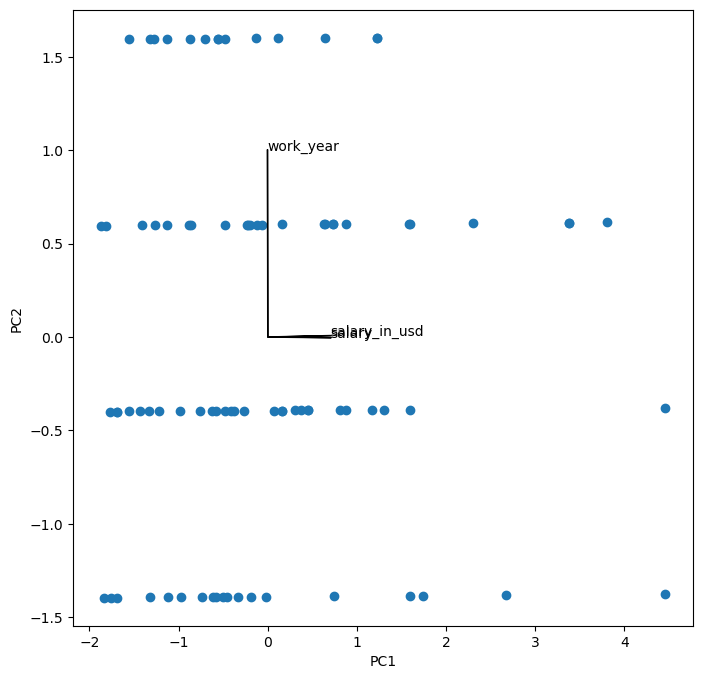

In [22]:
i, j = 0, 1 # which components
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pcaDS.components_.shape[1]):
    ax.arrow(0, 0, pcaDS.components_[i,k], pcaDS.components_[j,k])
    ax.text(pcaDS.components_[i,k],
            pcaDS.components_[j,k],
            clean_3.columns[k])

With titles added to this plot, it becomes much harder to interpret this plot due to most of these plots consolidting close to each other, but we can still uncover some insights here.

The consolidations are likely due having a similar work year, and the distances between each point is also likely due to work year as well.

Financial data analyst and research scientist contribute the PC1 scorers the most.

Work year has the largest length, meaning it strongly contribues to the PCA plot here.

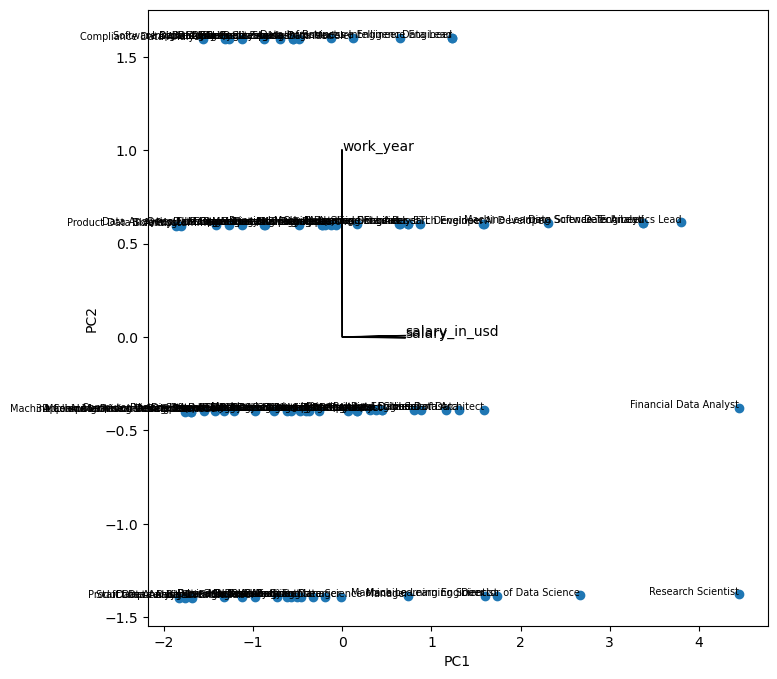

In [23]:
i, j = 0, 1 # which components
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pcaDS.components_.shape[1]):
    ax.arrow(0, 0, pcaDS.components_[i,k], pcaDS.components_[j,k])
    ax.text(pcaDS.components_[i,k],
            pcaDS.components_[j,k],
            clean_3.columns[k])
for idx in range(len(scores)):
    name = clean_3.index[idx]  # Get the name from the DataFrame index
    ax.text(scores[idx, 0], scores[idx, 1], name, fontsize=7, ha='right')

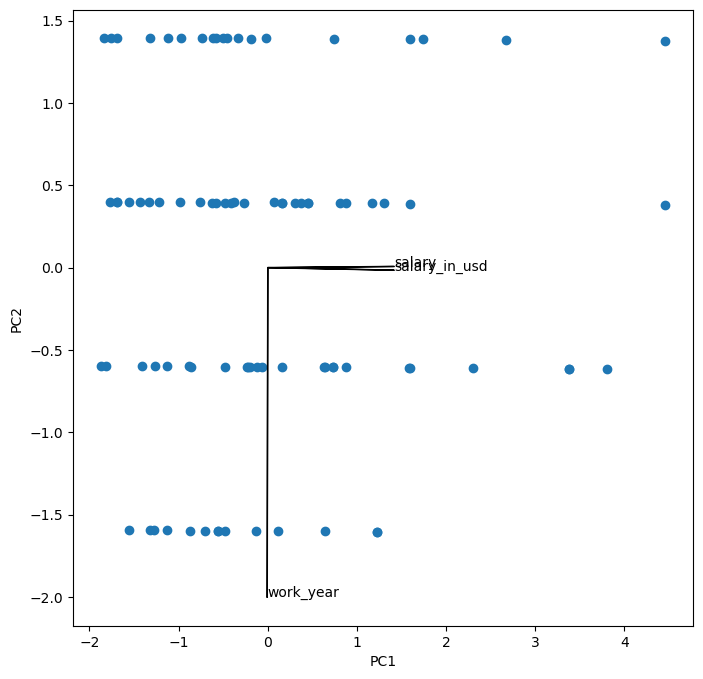

In [24]:
scale_arrow = s_ = 2
scores[:,1] *= -1
pcaDS.components_[1] *= -1 # flip the y-axis
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pcaDS.components_.shape[1]):
    ax.arrow(0, 0, s_*pcaDS.components_[i,k], s_*pcaDS.components_[j,k])
    ax.text(s_*pcaDS.components_[i,k],
            s_*pcaDS.components_[j,k],
            clean_3.columns[k])

In [25]:
scores.std(0, ddof=1)

array([1.42125613, 1.00589276, 0.05920209])

In [26]:
pcaDS.explained_variance_


array([2.01996898, 1.01182025, 0.00350489])

## IV. Create a scree plot and assess how much variation is explained by the principal components. Discuss whether the first two principal components provide a good representation for visualization in the biplot. If not, suggest how many principal components to use and explain why.

Our explained variance ratio here will give us a good sense how much variation is explained by the principal components. The first two principal components explain almost 100% of the variance in our data here and proivde a good representation of the visualization in the biplot since we have two variables that are very similar to each other, so two components in work +year one of the other salary components covers most of the variance in our model.

In [27]:
pcaDS.explained_variance_ratio_

array([0.66549366, 0.33335163, 0.00115471])

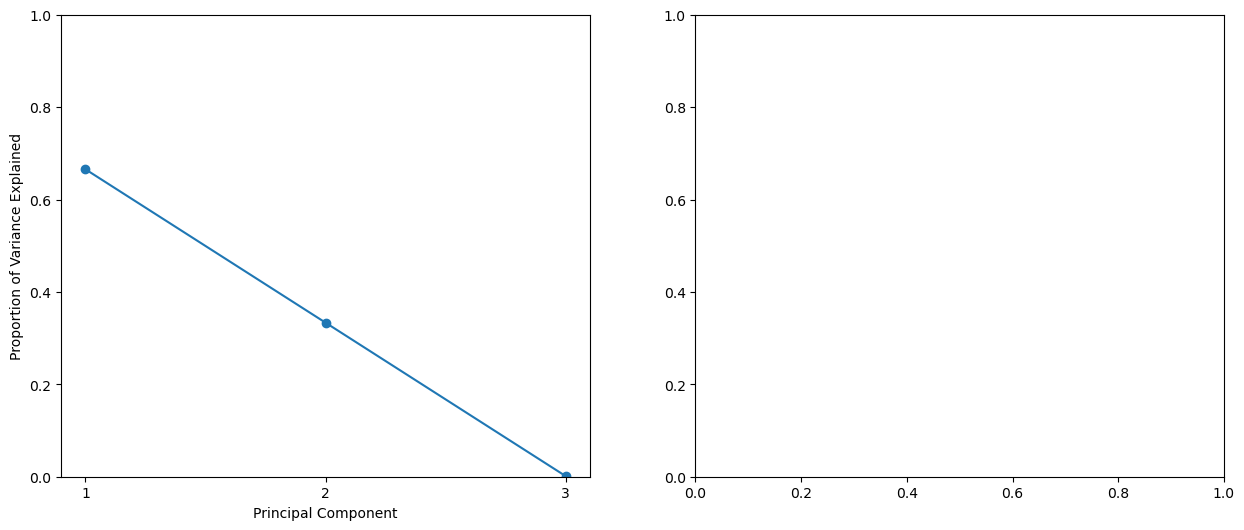

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ticks = np.arange(pcaDS.n_components_)+1
ax = axes[0]
ax.plot(ticks,
        pcaDS.explained_variance_ratio_,
        marker='o')
ax.set_xlabel('Principal Component');
ax.set_ylabel('Proportion of Variance Explained')
ax.set_ylim([0,1])
ax.set_xticks(ticks)

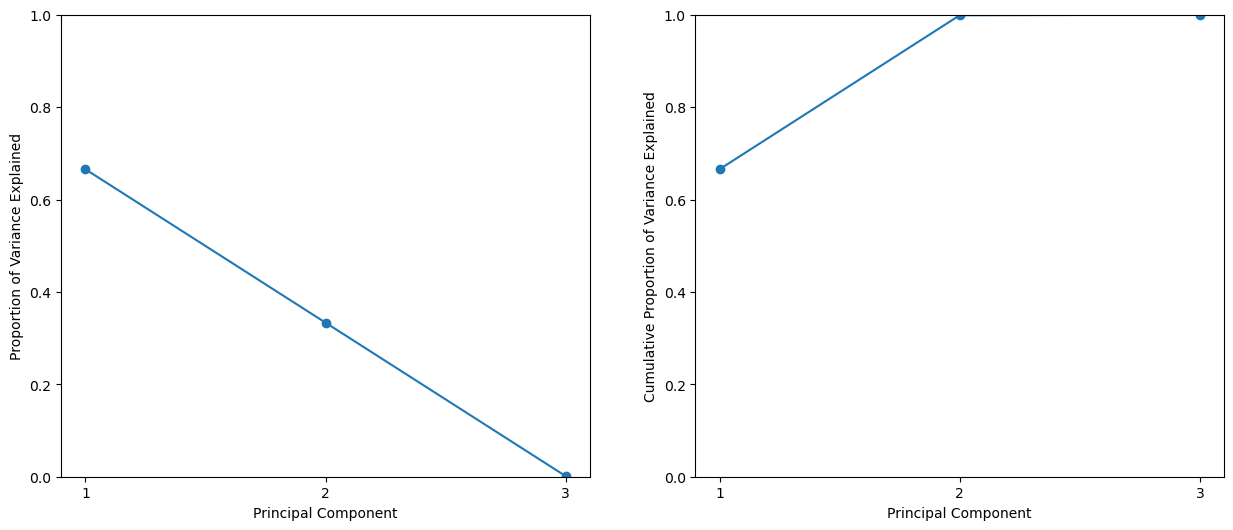

In [29]:
ax = axes[1]
ax.plot(ticks,
        pcaDS.explained_variance_ratio_.cumsum(),
        marker='o')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative Proportion of Variance Explained')
ax.set_ylim([0, 1])
ax.set_xticks(ticks)
fig


## Part 2. Principal components with missing values

## Using the dataset from Part 1, manually create some missing values so that you can compare the imputed values with the true values. Provide a hypothetical scenario of missing values under your project context. Explain how the missing values were created and justify the number or percentage of missing values used.

A good example of a hypothetical scenario where missing values would exist would be that either be that we would only have access to a US salary for an international job, but the exchange rate would be inaccessible, meaning we would not have access to the regular salary. 

Additionally, we might have detailed salary data, but missing the year for when that salary data is available. 

I believe the latter example discussed here is far more likely to occur than the initial example.

We can re-create our data above using singular value decomposition.

In [30]:
X = dsjobs_scaled
U, D, V = np.linalg.svd(X, full_matrices=False)
U.shape, D.shape, V.shape

((86, 3), (3,), (3, 3))

V represents the loading matrix, U represents the standardized PCA score matrix, and then the multiplication of term D gives the exact PCA scores.

In [31]:
V

array([[ 0.00292019, -0.707112  , -0.70709553],
       [-0.99996393,  0.00357483, -0.00770461],
       [-0.00797577, -0.70709252,  0.70707606]])

In [32]:
pcaDS.components_

array([[-0.00292019,  0.707112  ,  0.70709553],
       [-0.99996393,  0.00357483, -0.00770461],
       [ 0.00797577,  0.70709252, -0.70707606]])

In [33]:
(U * D[None,:])[:3]

array([[ 1.76234108,  1.39601625,  0.0029249 ],
       [ 0.61905137,  1.39264424,  0.00709662],
       [ 0.01912137,  1.39314852, -0.27578195]])

In [34]:
scores[:3]

array([[-1.76234108,  1.39601625, -0.0029249 ],
       [-0.61905137,  1.39264424, -0.00709662],
       [-0.01912137,  1.39314852,  0.27578195]])

We made the decision to omit 20 points as it represents around 20-25% of our data being missing.

In [35]:
n_omit = 20
np.random.seed(15)
r_idx = np.random.choice(np.arange(X.shape[0]),
                         n_omit,
                         replace=False)
c_idx = np.random.choice(np.arange(X.shape[1]),
                         n_omit,
                         replace=True)
Xna = X.copy()
Xna[r_idx, c_idx] = np.nan

The following function and vairables defined in the two cells below here represent imputing these nan values with the means for the missing values.

The copy is made here to not overwrite the initial data created.

In [36]:
def low_rank(X, M=1):
    U, D, V = np.linalg.svd(X)
    L = U[:,:M] * D[None,:M]
    return L.dot(V[:M])

In [37]:
Xhat = Xna.copy()
Xbar = np.nanmean(Xhat, axis=0)
Xhat[r_idx, c_idx] = Xbar[c_idx]

Our next step is creating a system that estimates the MSE based on the functions that we created and comparing the missing MSE to our original MSE in our data.

In [38]:
thresh = 1e-7
rel_err = 1
count = 0
ismiss = np.isnan(Xna)
mssold = np.mean(Xhat[~ismiss]**2)
mss0 = np.mean(Xna[~ismiss]**2)

In [39]:
while rel_err > thresh:
    count += 1
    # Step 2(a)
    Xapp = low_rank(Xhat, M=1)
    # Step 2(b)
    Xhat[ismiss] = Xapp[ismiss]
    # Step 2(c)
    mss = np.mean(((Xna - Xapp)[~ismiss])**2)
    rel_err = (mssold - mss) / mss0
    mssold = mss
    print("Iteration: {0}, MSS:{1:.3f}, Rel.Err {2:.2e}"
          .format(count, mss, rel_err))

Iteration: 1, MSS:0.319, Rel.Err 6.78e-01
Iteration: 2, MSS:0.311, Rel.Err 7.75e-03
Iteration: 3, MSS:0.310, Rel.Err 1.94e-03
Iteration: 4, MSS:0.309, Rel.Err 5.18e-04
Iteration: 5, MSS:0.309, Rel.Err 1.45e-04
Iteration: 6, MSS:0.309, Rel.Err 4.19e-05
Iteration: 7, MSS:0.309, Rel.Err 1.24e-05
Iteration: 8, MSS:0.309, Rel.Err 3.74e-06
Iteration: 9, MSS:0.309, Rel.Err 1.14e-06
Iteration: 10, MSS:0.309, Rel.Err 3.54e-07
Iteration: 11, MSS:0.309, Rel.Err 1.11e-07
Iteration: 12, MSS:0.309, Rel.Err 3.49e-08


Our MSE in this example ends up around 0.309, and our correlation ends up around 0.6364.

In [40]:
np.corrcoef(Xapp[ismiss], X[ismiss])[0,1]

np.float64(0.6363915161286365)